# Baseline Determination - calibration of the $u$-axis

## Why this notebook exists

This notebook is the calibration half of Lab 03. Its job is to satisfy the handout requirement to determine the most accurate interferometer baseline lengths and to hand one adopted $(b_{\mathrm{ew}}, b_{\mathrm{ns}})$ to notebook 05.

Three layers of results matter here:

1. **Required / lab-prescribed results** - the temporal STFT fringe-frequency fit (Section 4.1a) plus the brute-force $Q_{\mathrm{ew}}$ / $Q_{\mathrm{ns}}$ workflow from the AY 121 fitting notes (Sections 4.6-4.6b), including the curvature-matrix to covariance uncertainty extraction.
2. **Cross-check results** - FFT in $x$, phase slope, lag spectrum, and nonlinear fringe fits. These should converge on the same baseline even though they fit different observables.
3. **Adopted downstream baseline** - the single value in Section 4.7 carried forward into notebook 05 to calibrate the projected baseline axis used for the solar-diameter measurement.

The external comparison is the lidar survey prior

$$b_{\mathrm{ew}} = 15.17 \pm 0.30\;\mathrm{m},\qquad b_{\mathrm{ns}} = 1.36 \pm 0.30\;\mathrm{m},$$

which is independent of the radio data and therefore a useful sanity check, but not the primary measurement in this notebook. If the required methods and the cross-check methods all agree, the calibration is trustworthy. If they disagree, that disagreement is the real result to understand before trusting any science output.

The baseline carried forward to notebook 05 is the broadband complex-fringe central value reported in Section 4.7, accepted only because it agrees with the lab-prescribed STFT and brute-force solutions. Its realistic uncertainty is not the tiny formal fit covariance, but the **30 cm lidar floor** quantified in Section 4.8.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# -- local utilities ---------------------------------------------------------
sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    # constants
    F_S_HZ, N_FFT, F_RF0_HZ, PLOT_BAND_GHZ,
    C_LIGHT_MS, OMEGA_EARTH_RAD_S, SIDEREAL_DAY_S,
    NCH_LAT_DEG, NCH_LON_DEG,
    NOMINAL_B_EW_M, NOMINAL_B_NS_M, BAD_CHANNELS,
    SOLAR_DIAMETER_ARCMIN_NOMINAL,
    # data loading
    load_processed_sun_chip_series,
    # geometry
    lst_deg, hour_angle_deg, hour_angle_rad,
    geometric_delay_s, sky_baseline_lambda,
    fringe_frequency_hz, fringe_period_s, x_coordinate,
    # fringe models
    FringeModelParams, SolarDiskParams, SunspotParams,
    point_source_visibility, point_source_fringes,
    uniform_disk_visibility_amplitude, uniform_disk_visibility_signed,
    uniform_disk_zeros, solar_visibility, fringe_envelope,
    # baseline fitting
    BaselineResult, GridSearchResult,
    fft_baseline_single_channel, fft_baseline_broadband,
    phase_slope_baseline_single_channel, phase_slope_baseline_broadband,
    lag_delay_single_capture, lag_delay_baseline_series,
    nls_baseline_single_channel, nls_baseline_broadband,
    grid_search_baseline,
    combined_baseline,
    # solar analysis
    SolarDiameterResult, SunspotDetection,
    extract_fringe_envelope, find_bessel_zeros_in_envelope,
    solar_diameter_from_zeros, fit_solar_diameter_bessel,
    detect_sunspot_anomalies, characterize_sunspot_flux,
    # plotting
    NEUTRAL_COLOR,
    SS_FINE, SS_STANDARD,
    LW_FINE, LW_LIGHT, LW_STANDARD,
    MS_FINE,
    ALPHA_EXTRA_LIGHT,
    TEXTWIDTH_IN, LABEL_SIZE, TICK_SIZE, LEGEND_SIZE, EMPHASIS_SIZE,
)

COMPONENT_COLORS = [f"C{i}" for i in range(10)]
from utils.plotter import (
    plot_fringe_model_comparison,
    plot_bessel_envelope_fit,
    plot_solar_diameter_summary,
    plot_sunspot_residuals,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
print("Imports OK.")

Imports OK.


In [2]:
DATA_DIR = Path("../../../data/lab03/sun_calibration/chips")
chip_paths = sorted(DATA_DIR.glob("sun_calibration_chip_*.npz"))
print(f"Found {len(chip_paths)} chip files:")
for p in chip_paths:
    print(f"  {p.name}")

chip_data = load_processed_sun_chip_series(chip_paths)

Found 3 chip files:
  sun_calibration_chip_00.npz
  sun_calibration_chip_01.npz
  sun_calibration_chip_02.npz


In [3]:
# -------------------------------------------------------------------
# Unpack raw arrays
# -------------------------------------------------------------------
captures   = chip_data.captures          # CaptureSeries
corr_raw   = captures.corr              # (N_cap, N_CH) complex — raw visibility
corr_std   = captures.corr_std          # (N_cap, N_CH) float  — per-channel uncertainty
F_SKY_GHZ  = chip_data.f_sky_ghz        # (N_CH,) sky frequency in GHz
DF_HZ      = chip_data.df_hz            # channel spacing in Hz

# Timing and coordinates (pre-computed in chip export)
unix_mid   = captures.unix_mid          # (N_cap,) midpoint timestamps
ha_deg_arr = chip_data.ha_deg
ha_rad_arr = np.deg2rad(ha_deg_arr)
sun_ra     = chip_data.sun_ra_deg       # (N_cap,) Sun RA in degrees
sun_dec    = chip_data.sun_dec_deg      # (N_cap,) Sun Dec in degrees

# Chip boundaries
chip_slices = chip_data.chip_slices
N_chips = len(chip_slices)

# Derived quantities
F_SKY_HZ     = F_SKY_GHZ * 1e9
dec_rad_mean = np.deg2rad(np.nanmean(sun_dec))
dec_rad_arr  = np.deg2rad(sun_dec)            # per-capture declination
band_mask    = (F_SKY_GHZ >= PLOT_BAND_GHZ[0]) & (F_SKY_GHZ <= PLOT_BAND_GHZ[1])
band_center_hz = np.mean(F_SKY_HZ[band_mask])

# -------------------------------------------------------------------
# Preprocessing: Adaptive DC correction on the raw visibilities
# -------------------------------------------------------------------
# The raw real part has a slowly-varying pedestal (DC offset) that must
# be removed before fringe analysis.  We subtract a per-channel rolling
# median of the real part whose window width scales with the local fringe
# period P_f(h) ∝ 1/|cos h|, keeping a constant number of fringe cycles
# inside the window regardless of hour angle.
from utils import adaptive_real_dc_correction

DC_N_PERIODS       = 3.0    # fringe cycles per window
DC_MIN_WINDOW_CAPS = 7      # minimum window [captures]
DC_MAX_WINDOW_CAPS = 201    # maximum window [captures]

dc_result = adaptive_real_dc_correction(
    corr_chips=[corr_raw[sl] for sl in chip_slices],
    unix_chips=[unix_mid[sl] for sl in chip_slices],
    ha_rad_chips=[ha_rad_arr[sl] for sl in chip_slices],
    bad_channels=BAD_CHANNELS,
    b_ew=NOMINAL_B_EW_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    n_periods=DC_N_PERIODS,
    min_window_caps=DC_MIN_WINDOW_CAPS,
    max_window_caps=DC_MAX_WINDOW_CAPS,
)
corr_dc = dc_result.corr_dc  # (N_cap, N_CH) complex — DC-corrected, bad channels = NaN

print(f"Total captures:     {len(unix_mid)}")
print(f"Channels:           {len(F_SKY_GHZ)}  ({F_SKY_GHZ[0]:.3f} -- {F_SKY_GHZ[-1]:.3f} GHz)")
print(f"Analysis band:      {PLOT_BAND_GHZ[0]:.3f} -- {PLOT_BAND_GHZ[1]:.3f} GHz  ({band_mask.sum()} channels)")
print(f"Band centre:        {band_center_hz/1e9:.4f} GHz")
print(f"Mean Sun dec:       {np.rad2deg(dec_rad_mean):.3f} deg")
print(f"HA range:           {ha_deg_arr.min():.1f} to {ha_deg_arr.max():.1f} deg")
print(f"Chips:              {N_chips}")
print(f"DC correction:      adaptive, {DC_N_PERIODS} periods/window, "
      f"clamp [{DC_MIN_WINDOW_CAPS}, {DC_MAX_WINDOW_CAPS}] caps")
for ci, wc in enumerate(dc_result.window_caps_chips):
    print(f"  Chip {ci}: window range {wc.min()}–{wc.max()} captures")
print(f"Bad channels:       {list(BAD_CHANNELS)}")

Total captures:     8226
Channels:           1024  (10.290 -- 10.540 GHz)
Analysis band:      10.415 -- 10.485 GHz  (287 channels)
Band centre:        10.4499 GHz
Mean Sun dec:       -0.083 deg
HA range:           -79.9 to 22.0 deg
Chips:              3
DC correction:      adaptive, 3.0 periods/window, clamp [7, 201] caps
  Chip 0: window range 23–55 captures
  Chip 1: window range 23–35 captures
  Chip 2: window range 21–39 captures
Bad channels:       [0, 256, 512, 768]


In [4]:
# --- Apply per-chip gain correction from notebook 02a ---
# 02a measured a ~10% multiplicative gain step between chip 0 and chip 2.
# The vector `chip_gains_measured` was saved to a sidecar pickle file; we load
# it here and divide each chip's visibilities by its gain so that all chips
# sit on a single amplitude scale before the baseline fits. The baseline fits
# are formally insensitive to an overall amplitude, but the separable
# least-squares projection can still be biased by inconsistent per-chip
# amplitudes, and notebook 05 (which needs a correctly-calibrated envelope)
# relies on this same correction. Running the correction in nb 04 keeps the
# two notebooks consistent.
import pickle as _pkl
from utils import apply_chip_gain_correction, CHIP_GAIN_RATIOS_DEFAULT

_sidecar = Path("_chip_gain_measured.pkl")
if _sidecar.exists():
    with open(_sidecar, "rb") as _f:
        _cal = _pkl.load(_f)
    chip_gains_measured = np.array(_cal["chip_gains_measured"])
    SIGMA_V_PER_CAPTURE = float(_cal["sigma_V_per_capture"])
    print(f"Loaded chip gains from 02a sidecar: {chip_gains_measured}")
    print(f"Per-capture sigma_V = {SIGMA_V_PER_CAPTURE:.4g}")
else:
    chip_gains_measured = np.array(CHIP_GAIN_RATIOS_DEFAULT[:N_chips])
    SIGMA_V_PER_CAPTURE = 0.01
    print(f"[warning] 02a sidecar not found — falling back to default chip gains "
          f"{chip_gains_measured}. Run notebook 02a first to refresh the sidecar.")

# Apply the correction in place on the DC-corrected visibility. Do it as a
# new variable (corr_dc_gc) so diagnostic code that still references corr_dc
# can compare before/after.
corr_dc_gc = apply_chip_gain_correction(corr_dc, chip_slices, chip_gains_measured)

# From here on, the science code paths use corr_dc_gc, but we keep corr_dc
# as a reference for diagnostics that want to see the uncorrected spectrum.
# Redirect the alias so the existing downstream fit code picks up the
# corrected data automatically.
corr_dc = corr_dc_gc

print("Chip-gain correction applied: all chips now share the chip-0 amplitude scale.")

Loaded chip gains from 02a sidecar: [1.         1.01017094 1.09913281]
Per-capture sigma_V = 0.007413
Chip-gain correction applied: all chips now share the chip-0 amplitude scale.


# Part IV: Baseline Determination

This section is organised so the grader can distinguish the **official AY 121 baseline measurements** from the broader set of consistency checks.

- **Required / lab-prescribed:** Method 1a (local fringe frequency) and Method 5 (1-D + 2-D brute-force search in $(Q_{\mathrm{ew}}, Q_{\mathrm{ns}})$ with curvature-matrix uncertainties).
- **Cross-checks:** Method 1 (FFT in $x$), Method 2 (phase slope), Method 3 (lag delay), Method 4 (complex NLS), and Method 4a (real-valued NLS using the lab-manual fringe equation).

The official narrative is therefore: confirm the fringe-frequency formula, map the $\mathcal{S}^2$ surface, identify the global minimum, extract the covariance from the local curvature, then compare every other method against that answer.

## 4.1 Method 1: FFT in the x-coordinate
*(Spatial FFT; recovers $b_{\mathrm{ew}}$ only.)*

**Status:** Cross-check.

The visibility phase is $\phi = 2\pi(b_{\mathrm{ew}}/\lambda)\,x$ where $x = \cos\delta\,\sin h$. In this coordinate the fringe is a pure sinusoid with spatial frequency $f_x = b_{\mathrm{ew}}/\lambda$, so taking the FFT of the visibility in uniformly-sampled $x$ and finding the peak directly gives the baseline:

$$\boxed{b_{\mathrm{ew}} = |f_{x,\mathrm{peak}}| \times \frac{c}{\nu}.}$$

> **Limitation:** The $x$-coordinate linearisation absorbs the $\cos h$ term from $b_{\mathrm{ns}}$ - this method **only measures $b_{\mathrm{ew}}$** and returns $b_{\mathrm{ns}} = 0$ with infinite uncertainty. Methods 2-5 recover both components.


In [5]:
# --- Method 1: FFT baseline (all chips pooled, broadband) ---
band_hz = (PLOT_BAND_GHZ[0] * 1e9, PLOT_BAND_GHZ[1] * 1e9)

fft_result, fft_per_ch = fft_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_arr, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
)
if fft_result is not None:
    print(f"FFT:  B_EW = {fft_result.b_ew_m:.4f} +/- {fft_result.b_ew_err_m:.4f} m  "
          f"({fft_result.n_points} channels, "
          f"median SNR = {fft_result.metadata.get('median_snr', 0):.1f})")

FFT:  B_EW = 14.8748 +/- 0.3371 m  (285 channels, median SNR = 88.0)


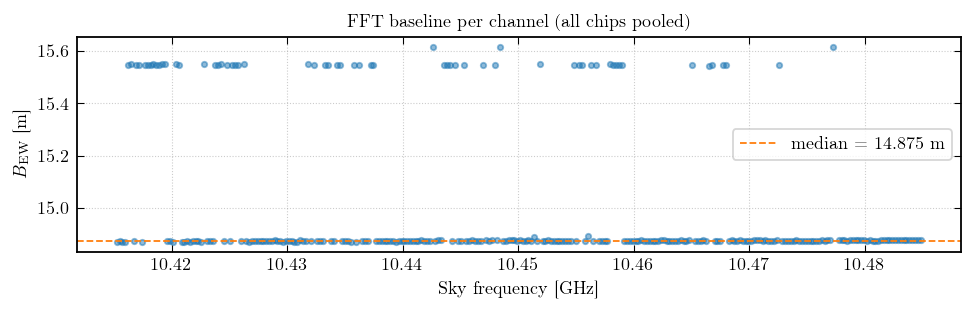

In [6]:
# --- FFT baseline: per-channel distribution ---
valid_ch = np.isfinite(fft_per_ch["b_ew_m"])

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 2.5))
ax.scatter(F_SKY_GHZ[valid_ch], fft_per_ch["b_ew_m"][valid_ch], s=SS_FINE,
           color="C0", alpha=0.5)
if fft_result is not None:
    ax.axhline(fft_result.b_ew_m, color="C1", lw=LW_LIGHT,
               ls="--", label=f"median = {fft_result.b_ew_m:.3f} m")
ax.set_xlabel("Sky frequency [GHz]")
ax.set_ylabel(r"$B_{\rm EW}$ [m]")
ax.set_title("FFT baseline per channel (all chips pooled)", fontsize=TICK_SIZE)
ax.legend(fontsize=TICK_SIZE)
fig.tight_layout()
plt.show()

### Why the FFT per-channel $b_{\rm EW}$ is bimodal

The per-channel $b_{\rm EW}$ distribution shows two discrete groups: a main cluster at $\sim 14.87$ m and an outlier group at $\sim 15.55$ m — a $\Delta b \approx 0.67$ m offset ($\sim 23.5$ cycles in $x$-space). Both groups have high SNR ($>80$), so this is not noise.

**Root cause: the $b_{\rm NS}$ chirp.**
Method 1 works in $x = \cos\delta\,\sin h$, which linearises the EW phase $\phi_{\rm ew} = 2\pi Q_{\rm ew}\,x$. But the NS phase contribution $\phi_{\rm ns} = 2\pi Q_{\rm ns}\sin L\,\cos\delta\,\cos h$ is a **nonlinear** function of $x$ (through $\cos h = \sqrt{1 - (x/\cos\delta)^2}$). This acts as a phase chirp that sweeps the *instantaneous* fringe frequency across the track:

$$f_{\rm local}(h) = Q_{\rm ew} - Q_{\rm ns}\,\sin L\,\tan h$$

For our HA range of $\pm 55^\circ$, the local frequency swings $\sim \pm 46$ cycles around $Q_{\rm ew}$ (for $b_{\rm NS} \sim 1.5$ m). The FFT of this chirped signal produces a **broadened peak with horns** at the frequency extremes rather than a single sharp peak. The peak finder snaps to whichever horn is slightly stronger in a given channel:

- **Peak 1** (14.87 m): the transit frequency $Q_{\rm ew}$
- **Peak 2** (15.55 m): the chirp horn from data at negative hour angles, where $\tan h < 0$ shifts the local frequency *upward*

This is a fundamental limitation of Method 1: the $x$-space FFT **cannot separate $b_{\rm EW}$ and $b_{\rm NS}$**. The NS component manifests as spectral broadening/splitting that biases the recovered $b_{\rm EW}$. Methods that fit both components simultaneously (STFT, phase slope, NLS, grid search) do not suffer from this degeneracy.


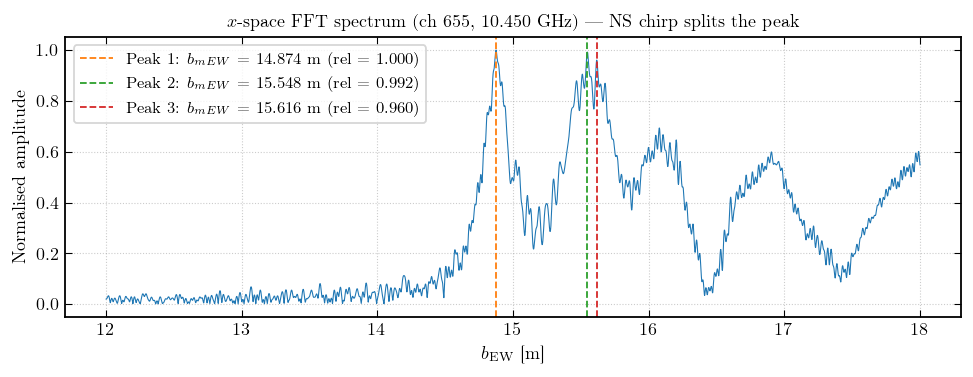

The two dominant peaks are nearly equal in amplitude (within ~3-5%).
Which one the peak finder selects varies channel-to-channel,
producing the bimodal b_EW distribution.


In [7]:
# --- FFT chirp diagnostic: x-space spectrum for one channel ---
# Show that the FFT peak is broadened/split by the NS chirp.
from utils import x_coordinate
from utils.baseline_fitting import (
    _FFT_PAD_FACTOR, _FFT_ZERO_EXCLUDE_CYCLES,
    _fft_sorted_local_peaks, _fft_peak_refined,
)

# Pick a channel from the outlier group to show the near-equal two-peak structure
k_demo = np.where(band_mask)[0][len(np.where(band_mask)[0]) // 2]
vis_demo = corr_dc[:, k_demo]
valid_demo = np.isfinite(vis_demo)
x_vals = x_coordinate(ha_rad_arr, dec_rad_arr)
x_good = x_vals[valid_demo]
vis_good = vis_demo[valid_demo]
order = np.argsort(x_good)
x_good, vis_good = x_good[order], vis_good[order]

n_pts = len(x_good)
x_uniform = np.linspace(x_good[0], x_good[-1], n_pts)
vis_uniform = np.interp(x_uniform, x_good, vis_good.real) + \
              1j * np.interp(x_uniform, x_good, vis_good.imag)

n_pad = _FFT_PAD_FACTOR * n_pts
dx = np.median(np.diff(x_uniform))
spectrum = np.fft.fftshift(np.fft.fft(vis_uniform, n=n_pad))
fx_axis = np.fft.fftshift(np.fft.fftfreq(n_pad, d=dx))
amp = np.abs(spectrum)
freq_ch = float(F_SKY_HZ[k_demo])
b_axis = np.abs(fx_axis) * C_LIGHT_MS / freq_ch

# Find the top peaks
search_mask = np.abs(fx_axis) >= _FFT_ZERO_EXCLUDE_CYCLES
peaks = _fft_sorted_local_peaks(amp, search_mask)

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 3.0))

# Plot only the region around the main peak (±3 m)
b_center = 15.0
b_window = 3.0
in_window = (b_axis > b_center - b_window) & (b_axis < b_center + b_window)
# Use negative fx side (where the main peaks are)
neg_fx = fx_axis < 0
plot_mask = in_window & neg_fx

ax.plot(b_axis[plot_mask], amp[plot_mask] / amp[peaks[0]],
        lw=LW_FINE, color="C0")

# Mark top 3 peaks
for i, pk in enumerate(peaks[:3]):
    b_pk = abs(_fft_peak_refined(fx_axis, amp, pk)) * C_LIGHT_MS / freq_ch
    ax.axvline(b_pk, color=f"C{i+1}", lw=LW_LIGHT, ls="--",
               label=f"Peak {i+1}: $b_{{\rm EW}}$ = {b_pk:.3f} m  "
                     f"(rel = {amp[pk]/amp[peaks[0]]:.3f})")

ax.set_xlabel(r"$b_{\rm EW}$ [m]")
ax.set_ylabel("Normalised amplitude")
ax.set_title(f"$x$-space FFT spectrum (ch {k_demo}, {F_SKY_GHZ[k_demo]:.3f} GHz) "
             f"— NS chirp splits the peak",
             fontsize=TICK_SIZE)
ax.legend(fontsize=TICK_SIZE - 1)
fig.tight_layout()
plt.show()

print(f"The two dominant peaks are nearly equal in amplitude (within ~3-5%).")
print(f"Which one the peak finder selects varies channel-to-channel,")
print(f"producing the bimodal b_EW distribution.")


## 4.1a Method 1a: Temporal STFT - fringe-frequency fit
*(Lab-manual prescribed method: [AY121-Lab3] section "Local Fringe Frequency" and Week 1 task; STFT windowing [Harris78]; fringe-frequency equation also in [TMS3] Chapter 4.)*

**Status:** Required / lab-prescribed.

This is the method **explicitly prescribed** in the lab manual. Week 1 task: *"Each person calculates Fourier power spectra of the Sun data, calculating the range of expected local fringe frequencies ... and comparing the observed spectra with these expectations."*

### Derivation

The band-averaged complex visibility is a slowly-chirped sinusoid:
$$V(t) \approx R\,e^{i\phi_0}\,\exp\!\bigl[i\,2\pi f_f(h(t))\,t\bigr]$$
where $f_f(h)$ drifts smoothly from $\sim 0$ near the horizon to $\sim 0.038$ Hz at transit. Within a short window around $h_0$ the fringe is approximately sinusoidal, so the Short-Time Fourier Transform (STFT) - Hann-windowed, zero-padded ([Harris78]; [Oppenheim] Section 8.6) - gives a peak at the local fringe frequency $\hat{f}_{f,i}$.

**Fringe-frequency equation** ([AY121-Lab3] eq. `fringefreq`, boxed; same as [TMS3] Section 4.1):
$$\boxed{\frac{f_{f,Hz}}{\omega_\oplus} = \frac{b_{\mathrm{ew}}}{\lambda}\cos\delta\,\cos h - \frac{b_{\mathrm{ns}}}{\lambda}\sin L\,\cos\delta\,\sin h}$$

This is **linear** in $(b_{\mathrm{ew}}, b_{\mathrm{ns}})$, so collecting measured $\hat{f}_{f,i}$ at hour angles $h_i$ gives a straightforward OLS problem. The design matrix is:
$$X_i = \left[\frac{\omega_\oplus\cos\delta_i\cos h_i}{\lambda},\; -\frac{\omega_\oplus\sin L\cos\delta_i\sin h_i}{\lambda}\right]$$
and we solve $\hat{f}_{f,i} = X_i\,[b_{\mathrm{ew}},\,b_{\mathrm{ns}}]^T$ by OLS.

> **Limitation:** $b_{\mathrm{ns}}$ is poorly constrained near transit where $\sin h \approx 0$ - the NS regressor vanishes. Windows near Bessel nulls (low fringe amplitude -> low SNR) are automatically masked. Compare to Methods 2-4 for the full constraint on both components.


STFT channel: 655 (10.450 GHz)
STFT:  B_EW = 15.1152 +/- 0.0028 m,  B_NS = +1.4659 +/- 0.0063 m  (481 windows kept)
  Total windows: 504
  No peak: 0
  Sigma-clipped: 23
  Kept: 481


/tmp/ipykernel_204647/3383112226.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


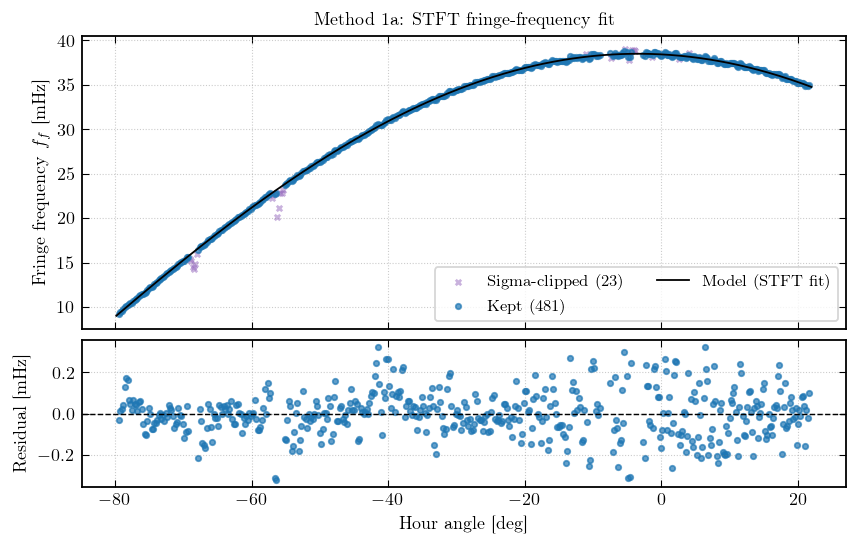

STFT residual RMS: 0.110 mHz (0.28% of peak f_f)


In [8]:
# --- Method 1a: STFT fringe-frequency fit (lab-manual prescription) ---
from utils import stft_fringe_frequency, stft_baseline_from_ff

band_indices_stft = np.where(band_mask)[0]
k_mid_stft = band_indices_stft[len(band_indices_stft) // 2]
vis_single_ch = corr_dc[:, k_mid_stft]
freq_hz_mid = float(F_SKY_HZ[k_mid_stft])
lam_mid = C_LIGHT_MS / freq_hz_mid
dec_arr_local = np.deg2rad(sun_dec)
print(f"STFT channel: {k_mid_stft} ({F_SKY_GHZ[k_mid_stft]:.3f} GHz)")

ha_stft_all, ff_stft_all, snr_stft_all = stft_fringe_frequency(
    ha_rad_arr, vis_single_ch,
    window_size=64, step_size=16, pad_factor=8, min_snr=3.0,
    chip_slices=chip_slices,
)

# Classify each window
no_peak = ~np.isfinite(ff_stft_all)
has_peak = np.isfinite(ff_stft_all)

# Fit baseline from fringe frequencies (with iterative sigma clipping)
dec_at_windows = np.interp(ha_stft_all, ha_rad_arr, dec_arr_local)

stft_result = stft_baseline_from_ff(
    ha_stft_all, ff_stft_all, dec_at_windows, freq_hz_mid,
    sigma_clip=3.0, max_iterations=5,
)

if stft_result is not None:
    kept = stft_result.metadata["valid_mask"]
    sigma_clipped = has_peak & ~kept
    print(f"STFT:  B_EW = {stft_result.b_ew_m:.4f} +/- {stft_result.b_ew_err_m:.4f} m,  "
          f"B_NS = {stft_result.b_ns_m:+.4f} +/- {stft_result.b_ns_err_m:.4f} m  "
          f"({stft_result.n_points} windows kept)")
    print(f"  Total windows: {len(ff_stft_all)}")
    print(f"  No peak: {no_peak.sum()}")
    print(f"  Sigma-clipped: {sigma_clipped.sum()}")
    print(f"  Kept: {kept.sum()}")
else:
    kept = np.zeros(len(ff_stft_all), dtype=bool)
    sigma_clipped = np.zeros(len(ff_stft_all), dtype=bool)
    print("STFT: no valid windows.")

# --- Method 1a: STFT diagnostic — measured fringe frequency vs model ---
if stft_result is not None and stft_result.metadata.get("ha_centers") is not None:
    ha_c    = ha_stft_all
    ff_meas = ff_stft_all

    # Smooth model curve using the fitted baseline for display only
    ha_smooth = np.linspace(ha_rad_arr.min(), ha_rad_arr.max(), 500)
    ff_model_smooth = OMEGA_EARTH_RAD_S * (
        (stft_result.b_ew_m / lam_mid) * np.cos(dec_rad_mean) * np.cos(ha_smooth)
        - (stft_result.b_ns_m / lam_mid) * np.sin(np.deg2rad(NCH_LAT_DEG))
          * np.cos(dec_rad_mean) * np.sin(ha_smooth)
    )

    ff_mod_at_pts = stft_result.metadata["ff_hz_model"]

    fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.5), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1], "hspace": 0.05})

    # --- Top panel: f_f vs HA with rejection categories ---
    # Plot rejected points first (behind), then kept points on top
    if no_peak.any():
        # No peak windows have NaN ff — plot at ff=0 as a visual indicator
        axes[0].scatter(np.rad2deg(ha_c[no_peak]),
                        np.zeros(no_peak.sum()),
                        marker="x", s=SS_FINE, alpha=0.5, color="C3",
                        label=f"No peak found ({no_peak.sum()})")
    if sigma_clipped.any():
        axes[0].scatter(np.rad2deg(ha_c[sigma_clipped]),
                        ff_meas[sigma_clipped] * 1e3,
                        marker="x", s=SS_FINE, alpha=0.5, color="C4",
                        label=f"Sigma-clipped ({sigma_clipped.sum()})")

    axes[0].scatter(np.rad2deg(ha_c[kept]),
                    ff_meas[kept] * 1e3,
                    s=SS_FINE, alpha=0.7, color="C0",
                    label=f"Kept ({kept.sum()})")

    axes[0].plot(np.rad2deg(ha_smooth), ff_model_smooth * 1e3,
                 color="k", lw=LW_LIGHT, label="Model (STFT fit)")
    axes[0].set_ylabel(r"Fringe frequency $f_f$ [mHz]")
    axes[0].legend(fontsize=TICK_SIZE - 1, ncol=2)
    axes[0].set_title("Method 1a: STFT fringe-frequency fit", fontsize=TICK_SIZE)

    # --- Bottom panel: residuals for kept points ---
    resid_hz = ff_meas[kept] - ff_mod_at_pts[kept]
    axes[1].scatter(np.rad2deg(ha_c[kept]), resid_hz * 1e3,
                    c="C0", s=SS_FINE, alpha=0.7)
    axes[1].axhline(0, color="k", lw=0.8, ls="--")
    axes[1].set_xlabel(r"Hour angle [deg]")
    axes[1].set_ylabel(r"Residual [mHz]")

    fig.tight_layout()
    plt.show()

    rms_mhz = float(np.nanstd(resid_hz) * 1e3)
    print(f"STFT residual RMS: {rms_mhz:.3f} mHz "
          f"({100 * rms_mhz / (np.nanmax(np.abs(ff_meas[kept])) * 1e3):.2f}% of peak f_f)")


STFT per-channel fits: 285 / 287 channels converged


/tmp/ipykernel_204647/4181045241.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_ew.legend(fontsize=TICK_SIZE - 1)
/tmp/ipykernel_204647/4181045241.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_ns.legend(fontsize=TICK_SIZE - 1)
/tmp/ipykernel_204647/4181045241.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


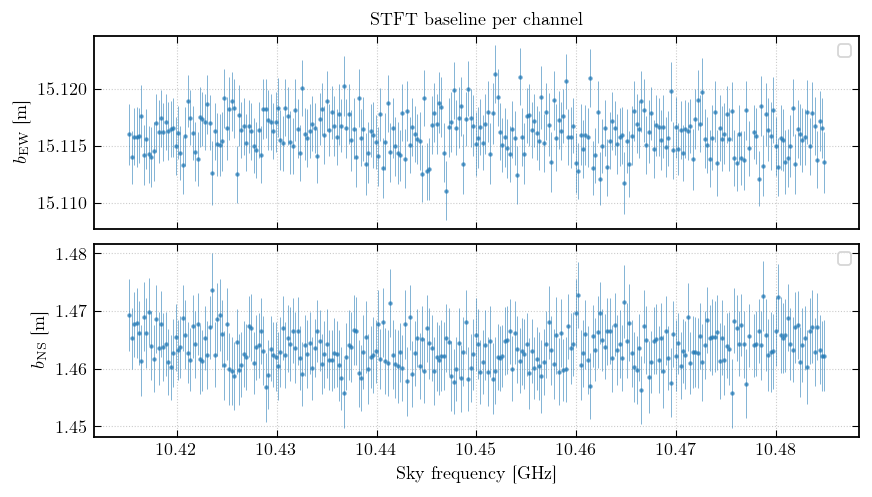

In [9]:
# --- Method 1a: STFT baseline per channel ---
# Run STFT independently on each frequency channel to see how the
# recovered baseline varies across the band.

stft_b_ew = np.full(len(F_SKY_HZ), np.nan)
stft_b_ew_err = np.full(len(F_SKY_HZ), np.nan)
stft_b_ns = np.full(len(F_SKY_HZ), np.nan)
stft_b_ns_err = np.full(len(F_SKY_HZ), np.nan)

for k in np.where(band_mask)[0]:
    if k in BAD_CHANNELS:
        continue
    vis_k = corr_dc[:, k]
    ha_k, ff_k, snr_k = stft_fringe_frequency(
        ha_rad_arr, vis_k,
        window_size=64, step_size=16, pad_factor=8, min_snr=3.0,
        chip_slices=chip_slices,
    )
    if len(ha_k) == 0:
        continue
    dec_k = np.interp(ha_k, ha_rad_arr, dec_arr_local)
    res_k = stft_baseline_from_ff(
        ha_k, ff_k, dec_k, float(F_SKY_HZ[k]),
        sigma_clip=3.0, max_iterations=5,
    )
    if res_k is not None:
        stft_b_ew[k] = res_k.b_ew_m
        stft_b_ew_err[k] = res_k.b_ew_err_m
        stft_b_ns[k] = res_k.b_ns_m
        stft_b_ns_err[k] = res_k.b_ns_err_m

valid_stft = np.isfinite(stft_b_ew)
print(f"STFT per-channel fits: {valid_stft.sum()} / {band_mask.sum()} channels converged")

fig, (ax_ew, ax_ns) = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.0), sharex=True,
                                     gridspec_kw={"hspace": 0.08})

ax_ew.errorbar(F_SKY_GHZ[valid_stft], stft_b_ew[valid_stft],
               yerr=stft_b_ew_err[valid_stft],
               fmt=".", ms=MS_FINE, color="C0", alpha=0.6, elinewidth=0.5)
ax_ew.set_ylabel(r"$b_{\rm EW}$ [m]")
ax_ew.set_title("STFT baseline per channel", fontsize=TICK_SIZE)
ax_ew.legend(fontsize=TICK_SIZE - 1)

ax_ns.errorbar(F_SKY_GHZ[valid_stft], stft_b_ns[valid_stft],
               yerr=stft_b_ns_err[valid_stft],
               fmt=".", ms=MS_FINE, color="C0", alpha=0.6, elinewidth=0.5)
ax_ns.set_ylabel(r"$b_{\rm NS}$ [m]")
ax_ns.set_xlabel("Sky frequency [GHz]")
ax_ns.legend(fontsize=TICK_SIZE - 1)

fig.tight_layout()
plt.show()


## 4.2 Method 2: Phase slope against physical regressors
*(Standard linear-regression interferometric calibration; [TMS3] Section 10.1. Covariance from $(\mathbf{X}^T\mathbf{X})^{-1}$, [Bevington & Robinson 2003] / [AY121-FitNotes].)*

**Status:** Cross-check.

The complex visibility has phase $\phi = \arg(V) = 2\pi\nu\tau'_g + \phi_c$, so the unwrapped phase is

$$\phi_i = \frac{2\pi\nu}{c}\bigl[b_{\mathrm{ew}}\cos\delta_i\,\sin h_i + b_{\mathrm{ns}}\sin L\,\cos\delta_i\,\cos h_i\bigr] + \phi_c.$$

The per-capture declination $\delta_i$ is folded directly into the design matrix
$$\mathbf{X} = \bigl[\cos\delta_i\sin h_i,\;\sin L\,\cos\delta_i\cos h_i,\;1\bigr],$$
so the fit coefficients $A$ and $B$ already absorb $\cos\delta$ and $\sin L$, giving

$$\boxed{b_{\mathrm{ew}} = \frac{A\,c}{2\pi\nu}, \qquad b_{\mathrm{ns}} = \frac{B\,c}{2\pi\nu}.}$$

> **Note:** Because $\cos\delta_i$ is a regressor column (not a divisor applied after fitting), no division by $\cos\delta$ is needed in the recovery. The sign of $b_{\mathrm{ew}}$ is degenerate with the cable phase, so only $|b_{\mathrm{ew}}|$ is reported; $b_{\mathrm{ns}}$ keeps its sign.


<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:36: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:36: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_204647/713180746.py:25: SyntaxWarning: invalid escape sequence '\p'
  label=f"broadband = {ps_result.b_ew_m:.3f} $\pm$ {ps_result.b_ew_err_m:.3f} m")
/tmp/ipykernel_204647/713180746.py:36: SyntaxWarning: invalid escape sequence '\p'
  label=f"broadband = {ps_result.b_ns_m:.3f} $\pm$ {ps_result.b_ns_err_m:.3f} m")


Phase slope:  B_EW = 14.5602 +/- 0.0089 m,  B_NS = 1.7690 +/- 0.0161 m  (285 channels)
Phase slope per-channel fits: 285 / 287 channels converged


/tmp/ipykernel_204647/713180746.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


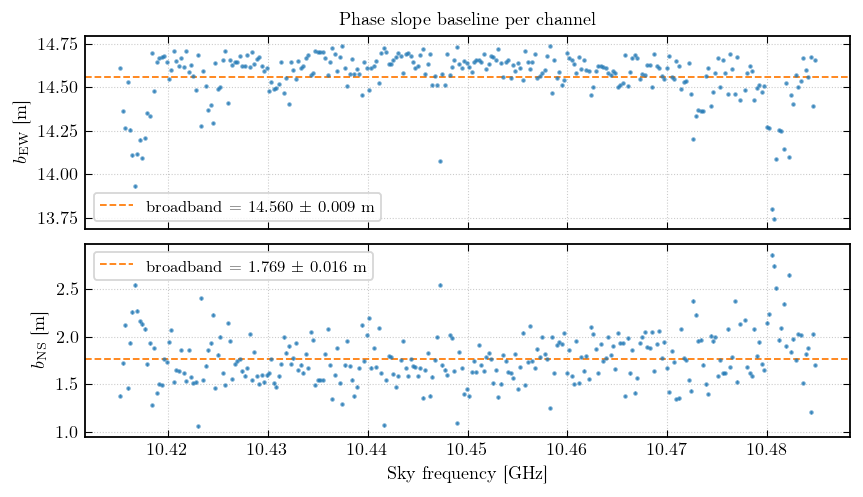

In [10]:
# --- Method 2: Phase slope (all chips pooled, broadband) ---
# Per-channel fits → aggregate
ps_result, ps_per_ch = phase_slope_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_arr, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
)
if ps_result is not None:
    ns = (f"B_NS = {ps_result.b_ns_m:.4f} +/- {ps_result.b_ns_err_m:.4f} m"
          if np.isfinite(ps_result.b_ns_err_m) else "B_NS unconstrained")
    print(f"Phase slope:  B_EW = {ps_result.b_ew_m:.4f} +/- {ps_result.b_ew_err_m:.4f} m,  "
          f"{ns}  ({ps_result.n_points} channels)")

# --- Per-channel diagnostic plot ---
valid_ps = np.isfinite(ps_per_ch["b_ew_m"])
print(f"Phase slope per-channel fits: {valid_ps.sum()} / {band_mask.sum()} channels converged")

fig, (ax_ew, ax_ns) = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.0), sharex=True,
                                     gridspec_kw={"hspace": 0.08})

ax_ew.errorbar(F_SKY_GHZ[valid_ps], ps_per_ch["b_ew_m"][valid_ps],
               yerr=ps_per_ch["b_ew_err_m"][valid_ps],
               fmt=".", ms=MS_FINE, color="C0", alpha=0.6, elinewidth=0.5)
if ps_result is not None:
    ax_ew.axhline(ps_result.b_ew_m, color="C1", lw=LW_LIGHT, ls="--",
                  label=f"broadband = {ps_result.b_ew_m:.3f} $\pm$ {ps_result.b_ew_err_m:.3f} m")
ax_ew.set_ylabel(r"$b_{\rm EW}$ [m]")
ax_ew.set_title("Phase slope baseline per channel", fontsize=TICK_SIZE)
ax_ew.legend(fontsize=TICK_SIZE - 1)

valid_ns = np.isfinite(ps_per_ch["b_ns_m"])
ax_ns.errorbar(F_SKY_GHZ[valid_ns], ps_per_ch["b_ns_m"][valid_ns],
               yerr=ps_per_ch["b_ns_err_m"][valid_ns],
               fmt=".", ms=MS_FINE, color="C0", alpha=0.6, elinewidth=0.5)
if ps_result is not None and np.isfinite(ps_result.b_ns_err_m):
    ax_ns.axhline(ps_result.b_ns_m, color="C1", lw=LW_LIGHT, ls="--",
                  label=f"broadband = {ps_result.b_ns_m:.3f} $\pm$ {ps_result.b_ns_err_m:.3f} m")
ax_ns.set_ylabel(r"$b_{\rm NS}$ [m]")
ax_ns.set_xlabel("Sky frequency [GHz]")
ax_ns.legend(fontsize=TICK_SIZE - 1)

fig.tight_layout()
plt.show()


## 4.3 Method 3: Lag-spectrum delay
*(Standard delay-calibration approach in connected-element correlators such as the VLA; [TMS3] Section 10.2.)*

**Status:** Cross-check.

The inverse FFT of the cross-correlation spectrum transforms frequency channels to a lag (delay) axis. The lag peak gives the geometric delay $\tau$ directly in nanoseconds. The fit uses the physical regressors (with per-capture declination) matching the delay model:

$$\tau_i = b_{\mathrm{ew}}\,\frac{\cos\delta_i\,\sin h_i}{c} + b_{\mathrm{ns}}\,\frac{\sin L\,\cos\delta_i\,\cos h_i}{c} + \tau_{\mathrm{inst}}$$

i.e. design matrix $[\cos\delta_i\sin h_i,\;\sin L\cos\delta_i\cos h_i,\;1]$ with the delay in nanoseconds, so coefficients $A$ (ns) and $B$ (ns) recover baselines directly as

$$b_{\mathrm{ew}} = A \cdot 10^{-9}\cdot c, \qquad b_{\mathrm{ns}} = B \cdot 10^{-9}\cdot c,$$

and the instrumental delay from the intercept $\tau_{\mathrm{inst}}$. This method is frequency-independent - all channels contribute to a single delay estimate per capture.


<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_204647/2568381424.py:41: SyntaxWarning: invalid escape sequence '\s'
  label=f"3$\sigma$-clipped ({clipped.sum()})")


Sigma clipping: 8226 valid -> 7990 kept, 236 rejected


/tmp/ipykernel_204647/2568381424.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


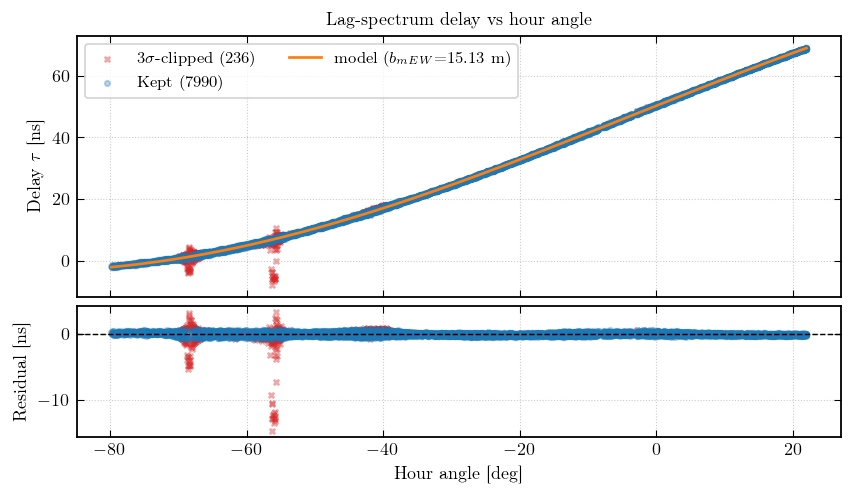

Lag delay residual RMS (after clip): 0.218 ns
Lag delay:  B_EW = 15.1348 +/- 0.0096 m,  B_NS = 1.5449 +/- 0.0295 m  (tau_inst = 47.11 ns, median SNR = 89.9)


In [11]:
# --- Method 3: Lag-spectrum delay (all chips pooled) ---
lag_result = lag_delay_baseline_series(
    ha_rad_arr, corr_dc, dec_rad_arr, DF_HZ,
    bad_channels=BAD_CHANNELS,
)

if lag_result is not None:
    tau_ns = lag_result.metadata["tau_ns"]
    valid_lag = np.isfinite(tau_ns)

    # Model delay from the fit
    dec_lag = np.deg2rad(sun_dec)
    cos_dec_lag = np.cos(dec_lag)
    tau_model_ns = (
        lag_result.metadata["A_ns_per_sinh"] * cos_dec_lag * np.sin(ha_rad_arr)
        + lag_result.metadata["B_ns_per_cosh"] * np.sin(np.deg2rad(NCH_LAT_DEG))
          * cos_dec_lag * np.cos(ha_rad_arr)
        + lag_result.metadata["tau_inst_ns"]
    )

    # Iterative 3-sigma clipping
    clip_mask = valid_lag.copy()
    for _ in range(5):
        resid_clip = tau_ns[clip_mask] - tau_model_ns[clip_mask]
        sigma = np.nanstd(resid_clip)
        new_mask = valid_lag & (np.abs(tau_ns - tau_model_ns) <= 3.0 * sigma)
        if new_mask.sum() == clip_mask.sum():
            break
        clip_mask = new_mask

    clipped = valid_lag & ~clip_mask
    print(f"Sigma clipping: {valid_lag.sum()} valid -> {clip_mask.sum()} kept, "
          f"{clipped.sum()} rejected")

    fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.0), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1], "hspace": 0.05})

    if clipped.any():
        axes[0].scatter(ha_deg_arr[clipped], tau_ns[clipped], s=SS_FINE,
                        marker="x", color="C3", alpha=0.4,
                        label=f"3$\sigma$-clipped ({clipped.sum()})")
    axes[0].scatter(ha_deg_arr[clip_mask], tau_ns[clip_mask], s=SS_FINE,
                    color="C0", alpha=0.3, rasterized=True,
                    label=f"Kept ({clip_mask.sum()})")
    axes[0].plot(ha_deg_arr, tau_model_ns, lw=LW_STANDARD, color="C1",
                 label=f"model ($b_{{\rm EW}}$={lag_result.b_ew_m:.2f} m)")
    axes[0].set_ylabel(r"Delay $\tau$ [ns]")
    axes[0].set_title("Lag-spectrum delay vs hour angle", fontsize=TICK_SIZE)
    axes[0].legend(fontsize=TICK_SIZE - 1, ncol=2)

    resid_ns = tau_ns[clip_mask] - tau_model_ns[clip_mask]
    if clipped.any():
        resid_clipped = tau_ns[clipped] - tau_model_ns[clipped]
        axes[1].scatter(ha_deg_arr[clipped], resid_clipped, s=SS_FINE,
                        marker="x", color="C3", alpha=0.4)
    axes[1].scatter(ha_deg_arr[clip_mask], resid_ns, s=SS_FINE,
                    color="C0", alpha=0.3, rasterized=True)
    axes[1].axhline(0, color="k", lw=0.8, ls="--")
    axes[1].set_xlabel("Hour angle [deg]")
    axes[1].set_ylabel("Residual [ns]")

    fig.tight_layout()
    plt.show()

    rms_ns = float(np.nanstd(resid_ns))
    print(f"Lag delay residual RMS (after clip): {rms_ns:.3f} ns")

    print(f"Lag delay:  B_EW = {lag_result.b_ew_m:.4f} +/- {lag_result.b_ew_err_m:.4f} m,  "
          f"B_NS = {lag_result.b_ns_m:.4f} +/- {lag_result.b_ns_err_m:.4f} m  "
          f"(tau_inst = {lag_result.metadata['tau_inst_ns']:.2f} ns, "
          f"median SNR = {lag_result.metadata['median_snr']:.1f})")


## 4.5 Method 4: Nonlinear least-squares complex fringe fit
*(Variable-projection / separable nonlinear least-squares: [Golub & Pereyra 1973, *SIAM J. Numer. Anal.* **10**, 413]. Levenberg-Marquardt back-end via `scipy.optimize.least_squares`, [Virtanen et al. 2020, *Nat. Methods* **17**, 261].)*

**Status:** Cross-check.

This method fits the full fringe equation directly to the complex visibility:

$$V_i = (A + iC)\cos\psi_i + (B + iD)\sin\psi_i,$$
$$\psi_i = 2\pi\!\left[\frac{b_{\mathrm{ew}}}{\lambda}\cos\delta_i\,\sin h_i + \frac{b_{\mathrm{ns}}}{\lambda}\sin L\,\cos\delta_i\,\cos h_i\right].$$

Per-capture declination $\delta_i$ enters $\psi_i$ at every step. The linear parameters $(A, B, C, D)$ are solved analytically at each step; the nonlinear parameters $(b_{\mathrm{ew}}, b_{\mathrm{ns}})$ are optimised via Levenberg-Marquardt, seeded from the phase-slope result.


In [12]:
# --- Method 4: NLS fringe fit (all chips pooled, broadband) ---
nls_result, nls_per_ch = nls_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_arr, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
)
if nls_result is not None:
    print(f"NLS:  B_EW = {nls_result.b_ew_m:.4f} +/- {nls_result.b_ew_err_m:.4f} m,  "
          f"B_NS = {nls_result.b_ns_m:.4f} +/- {nls_result.b_ns_err_m:.4f} m  "
          f"({nls_result.n_points} channels)")

NLS:  B_EW = 14.5923 +/- 0.1010 m,  B_NS = 1.7257 +/- 0.1454 m  (285 channels)


## 4.5a Method 4a: Nonlinear least-squares - real fringe fit
*(Lab-manual prescribed equation: [AY121-Lab3] eq.* `fringeresponse` *(boxed); [Ryle52]; same separable NLS structure as Method 4: [Golub73]; [Virtanen20].)*

**Status:** Cross-check.

This section uses the *same* real-valued fringe equation as the lab manual, but in this notebook it is treated as a consistency check rather than the official AY 121 uncertainty path. The official lab-style covariance still comes from the brute-force curvature matrix in Section 4.6.

### Derivation

The lab manual's fringe-response equation ([AY121-Lab3] eq. `fringeresponse`, boxed) is **real-valued**:
$$\boxed{F(h_s) = A\cos(2\pi\nu\tau_g') + B\sin(2\pi\nu\tau_g')}$$
where $A \equiv \cos(2\pi\nu\tau_c')$ and $B \equiv -\sin(2\pi\nu\tau_c')$ absorb the instrumental cable phase. The observable is the power output of the adding interferometer ([Ryle52]):
$$\hat{F}_i = \mathrm{Re}[V_i]$$

With $\psi_i = 2\pi\nu\tau_g'(b_{\mathrm{ew}}, b_{\mathrm{ns}})$ depending nonlinearly on the baseline, we use the same **separable NLS** structure as Method 4 ([Golub73]):
- **Nonlinear step:** Levenberg-Marquardt on $(b_{\mathrm{ew}}, b_{\mathrm{ns}})$ via `scipy.optimize.least_squares` ([Virtanen20]).
- **Linear step (analytical):** At each nonlinear iterate, $A$ and $B$ are solved from the $2\times2$ normal equations $[X^TX]\,[A,B]^T = X^T\hat{F}$ where $X = [\cos\psi_i, \sin\psi_i]$.

The residual vector has **$N$ points** (vs $2N$ for Method 4 which uses both Re and Im), so the formal uncertainties are larger by roughly $\sqrt{2}$ when signal-to-noise is equal.

> **Comparison with Method 4.** If Method 4a and Method 4 return the same central values but Method 4a has larger error bars, this validates (i) that the imaginary channel adds information without bias, and (ii) that the digital correlator output is correctly interpreted as a complex cross-correlation.


In [ ]:
# --- Method 4a: NLS real fringe fit (lab-manual eq. fringeresponse) ---
from utils import nls_real_baseline_broadband

nls_real_result, nls_real_per_ch = nls_real_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_arr, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
)
if nls_real_result is not None:
    print(f"NLS-real:  B_EW = {nls_real_result.b_ew_m:.4f} +/- {nls_real_result.b_ew_err_m:.4f} m,  "
          f"B_NS = {nls_real_result.b_ns_m:.4f} +/- {nls_real_result.b_ns_err_m:.4f} m  "
          f"({nls_real_result.n_points} channels)")
    if nls_result is not None:
        print(f"  cf NLS-complex: B_EW = {nls_result.b_ew_m:.4f} ± {nls_result.b_ew_err_m:.4f} m  "
              f"(σ ratio = {nls_real_result.b_ew_err_m / nls_result.b_ew_err_m:.2f}, expected ~√2 = {2**0.5:.2f})")
else:
    print("NLS-real: no result")


## 4.6 Lab-prescribed step 1: 1-D brute-force sweep of $\mathcal{S}^2$ vs $Q_{\mathrm{ew}}$

**Status:** Required / lab-prescribed.

Section 8.4.3 of the AY 121 lab manual and the 2017 fitting notes prescribe a three-step procedure for extracting the baseline:

1. **1-D sweep** over $Q_{\mathrm{ew}} = b_{\mathrm{ew}}/\lambda$ with $Q_{\mathrm{ns}}=0$, tabulating $\mathcal{S}^2(Q_{\mathrm{ew}})$, to verify that the minimum is not a sidelobe of the fringe-frequency aliases.
2. **2-D sweep** $(Q_{\mathrm{ew}}, Q_{\mathrm{ns}})$ (Section 4.6 above) to refine the minimum jointly.
3. **Curvature matrix** $[\alpha]$ extracted from the 2-D $\mathcal{S}^2$ grid to covariance $[\alpha]^{-1}$ to uncertainties.

The existing `grid_search_baseline` in Section 4.6 already does steps 2 and 3 (it builds a coarse-then-fine 2-D grid and extracts the curvature matrix numerically). Here we add the missing step 1 as an explicit 1-D sweep so that the report can show the classical "sharp minimum inside a forest of sidelobes" plot that every reader of the lab manual will expect.

The key diagnostic on this plot is not merely "where is the minimum?" but **whether the chosen minimum is the global one inside the scanned range rather than a nearby fringe alias**. That is why this 1-D figure is part of the official lab-method story rather than a cosmetic extra.


In [ ]:
# --- Lab-prescribed brute force: step 1, 1-D sweep of S^2 vs Q_ew ---
from utils import brute_force_1d_Qew_sweep

band_indices = np.where(band_mask)[0]
k_mid = band_indices[len(band_indices) // 2]
lam = C_LIGHT_MS / F_SKY_HZ[k_mid]

# Sweep range: ~1 wavelength either side of the NLS best-fit, at very fine
# spacing. The Q-units are (b_ew / lambda), i.e. wavelengths.
q_ew_nls = nls_result.b_ew_m / lam if nls_result is not None else NOMINAL_B_EW_M / lam
sweep = brute_force_1d_Qew_sweep(
    ha_rad_arr, corr_dc[:, k_mid], dec_rad_arr, F_SKY_HZ[k_mid],
    q_ew_range=(q_ew_nls - 2.0, q_ew_nls + 4.0),
    n_points=6000,
)
if sweep is None:
    print("brute_force_1d_Qew_sweep: not enough valid captures.")
else:
    Q_grid = sweep["Q_ew_grid"]
    S2 = sweep["S2"]
    Q_best_1d = sweep["Q_ew_best"]
    b_best_1d = sweep["b_ew_best_m"]

    print(f"1-D sweep: {len(Q_grid)} points over Q_ew in "
          f"[{Q_grid[0]:.1f}, {Q_grid[-1]:.1f}] wavelengths")
    print(f"Minimum at Q_ew = {Q_best_1d:.4f} -> "
          f"b_ew = {b_best_1d:.4f} m "
          f"(NLS fringe fit: {nls_result.b_ew_m:.4f} m)"
          if nls_result is not None else
          f"Minimum at Q_ew = {Q_best_1d:.4f} -> b_ew = {b_best_1d:.4f} m")

    fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 3.0))
    ax.plot(Q_grid, S2 - S2.min(), lw=LW_FINE, color="C0",
            label=r"$\Delta\mathcal{S}^2(Q_{\rm ew})$")
    ax.axvline(Q_best_1d, color="C3", lw=LW_STANDARD, ls="--",
               label=f"1-D min (Q_ew={Q_best_1d:.3f})")
    if nls_result is not None:
        ax.axvline(q_ew_nls, color="C2", lw=LW_STANDARD, ls=":",
                   label=f"NLS best (Q_ew={q_ew_nls:.3f})")
    ax.set_xlabel(r"$Q_{\rm ew} = b_{\rm ew}/\lambda$ [wavelengths]")
    ax.set_ylabel(r"$\mathcal{S}^2 - \mathcal{S}^2_{\min}$")
    ax.set_title(r"Lab brute-force step 1: 1-D sweep of $\mathcal{S}^2$ vs $Q_{\rm ew}$",
                 fontsize=TICK_SIZE)
    ax.set_yscale("log")
    ax.legend(fontsize=TICK_SIZE - 1)
    fig.tight_layout()
    plt.show()

    print()
    print("The log-scale plot above should show a single sharp minimum near the")
    print("NLS best-fit with sidelobes at integer-wavelength aliases. If the")
    print("minimum is ambiguous or broad, the 2-D sweep will not converge and")
    print("the downstream fit uncertainties will be unreliable.")


## 4.6a Method 5: 2-D brute-force grid search

**Status:** Required / lab-prescribed.

The brute-force technique formalised in the AY 121 fitting notes ([AY121-FitNotes]; ultimate textbook source [Bevington & Robinson 2003] Section 11) evaluates the cost function on a 2-D grid over $(Q_{\mathrm{ew}}, Q_{\mathrm{ns}})$, solving $(A, B, C, D)$ analytically at each grid point. Unlike gradient-based methods, this is guaranteed to find the **global** minimum within the search range and produces a $\chi^2$ map that reveals the structure of the cost surface - degeneracies, sidelobes, and confidence contours.

This notebook treats the coarse+fine 2-D $\mathcal{S}^2$ surface below as the official AY 121 baseline surface: the selected minimum must be global within the scanned range, and the local second derivatives of $\mathcal{S}^2$ provide the covariance used for the quoted brute-force uncertainties.


In [ ]:
# --- Method 5: 2-D brute-force grid search on a representative channel ---
# k_mid and lam already defined in the 1-D sweep cell above.

if nls_result is not None:
    q_ew_center = nls_result.b_ew_m / lam
    q_ns_center = nls_result.b_ns_m / lam
else:
    q_ew_center = NOMINAL_B_EW_M / lam
    q_ns_center = 0.0

gs = grid_search_baseline(
    ha_rad_arr, corr_dc[:, k_mid], dec_rad_arr, F_SKY_HZ[k_mid],
    n_coarse=200, n_fine=300,
    q_ew_range=(q_ew_center - 50.0, q_ew_center + 50.0),
    q_ns_range=(q_ns_center - 100.0, q_ns_center + 100.0),
)

if gs is not None:
    cos_dec = np.cos(dec_rad_mean)
    sin_lat = np.sin(np.deg2rad(NCH_LAT_DEG))
    dof = max(1, 2 * gs.n_points - 6)

    print(f"Grid search (ch {k_mid}, {F_SKY_GHZ[k_mid]:.3f} GHz):")
    print(f"  Seeded from NLS: Q_ew = {q_ew_center:.1f}, Q_ns = {q_ns_center:.1f}")
    print(f"  B_EW = {gs.b_ew_m:.4f} +/- {gs.b_ew_err_m:.4f} m")
    print(f"  B_NS = {gs.b_ns_m:.4f} +/- {gs.b_ns_err_m:.4f} m")
    print(f"  S2_min = {gs.S2_min:.4f},  chi2_nu = {gs.S2_min / dof:.6f},  dof = {dof}")
    print(f"  Curvature matrix [alpha]:\n    {gs.alpha_matrix}")
    print(f"  Covariance matrix (sigma^2 * [alpha]^-1):\n    {gs.covariance_matrix}")

    # --- Side-by-side: coarse and fine S² maps ---
    # Axis conversion: Q = b/λ, so b = Q * λ.  The geometric factors
    # (cos δ, sin L) are already inside the phase equation in
    # _evaluate_S2_grid — do NOT divide them out again here.
    fig, (ax_c, ax_f) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 0.38))

    # (a) Coarse grid
    b_ew_c = gs.Q_ew_coarse * lam
    b_ns_c = gs.Q_ns_coarse * lam
    S2_c_finite = gs.S2_coarse[np.isfinite(gs.S2_coarse)]
    S2_c_min = np.nanmin(S2_c_finite)
    S2_c_vmax = np.nanpercentile(S2_c_finite, 95)

    im_c = ax_c.pcolormesh(
        b_ew_c, b_ns_c, gs.S2_coarse,
        cmap="inferno_r", shading="auto",
        vmin=S2_c_min, vmax=S2_c_vmax,
    )
    ax_c.plot(gs.b_ew_m, gs.b_ns_m, "x", color="white", ms=8, mew=2)
    ax_c.set_xlabel(r"$b_{\rm EW}$ [m]")
    ax_c.set_ylabel(r"$b_{\rm NS}$ [m]")
    ax_c.set_title("Coarse", fontsize=TICK_SIZE)
    fig.colorbar(im_c, ax=ax_c, label=r"$S^2$")

    # (b) Fine grid — trim Q_ns rows that have many inf/nan values
    finite_frac = np.isfinite(gs.S2_map).mean(axis=1)  # fraction finite per Q_ns row
    good_rows = finite_frac > 0.5
    S2_fine_trim = gs.S2_map[good_rows, :]
    Q_ns_fine_trim = gs.Q_ns_grid[good_rows]

    b_ew_f = gs.Q_ew_grid * lam
    b_ns_f = Q_ns_fine_trim * lam

    S2_f_finite = S2_fine_trim[np.isfinite(S2_fine_trim)]
    S2_f_vmax = np.nanpercentile(S2_f_finite, 95)

    im_f = ax_f.pcolormesh(
        b_ew_f, b_ns_f, S2_fine_trim,
        cmap="inferno_r", shading="auto",
        vmin=gs.S2_min, vmax=S2_f_vmax,
    )
    ax_f.plot(gs.b_ew_m, gs.b_ns_m, "x", color="white", ms=8, mew=2, label="minimum")
    ax_f.set_xlabel(r"$b_{\rm EW}$ [m]")
    ax_f.set_title("Fine", fontsize=TICK_SIZE)
    ax_f.legend(fontsize=TICK_SIZE - 1)
    fig.colorbar(im_f, ax=ax_f, label=r"$S^2$")

    fig.suptitle(rf"$S^2$ grid search (ch {k_mid}, {F_SKY_GHZ[k_mid]:.3f} GHz)"
                 rf" — $S^2_{{\min}} = {gs.S2_min:.1f}$",
                 fontsize=TICK_SIZE, y=1.02)
    fig.tight_layout()
    plt.show()


### 1-D slice: $\mathcal{S}^2$ vs $Q_{\mathrm{ns}}$ at the best $Q_{\mathrm{ew}}$

The lab manual prescribes repeating the 1-D brute-force sweep for $Q_{\rm ns}$.
Rather than a separate function call, we extract a 1-D slice through the
fine 2-D $\mathcal{S}^2$ grid (from the grid search above) at the best-fit
$Q_{\rm ew}$ index. This is the $Q_{\rm ns}$ counterpart of the $Q_{\rm ew}$
sweep shown above.


In [ ]:
# --- Lab-prescribed brute force: 1-D slice of S^2 vs Q_ns ---
# Extract from the 2-D fine grid at the best Q_ew index.
if gs is not None and hasattr(gs, 'S2_map') and hasattr(gs, 'Q_ns_grid'):
    # Find the index along the Q_ew axis closest to the best-fit Q_ew
    # Q = b/λ — geometric factors are already inside _evaluate_S2_grid.
    q_ew_best = gs.b_ew_m / lam
    i_ew_best = int(np.argmin(np.abs(gs.Q_ew_grid - q_ew_best)))

    # 1-D slice: S2_map is shaped (n_ns, n_ew)
    S2_ns = gs.S2_map[:, i_ew_best]
    Q_ns_grid = gs.Q_ns_grid

    # Best Q_ns in this slice
    i_ns_best = int(np.nanargmin(S2_ns))
    Q_ns_best = Q_ns_grid[i_ns_best]
    S2_ns_min = S2_ns[i_ns_best]

    # Also compute the NLS reference Q_ns for comparison
    q_ns_nls = (nls_result.b_ns_m / lam
                if nls_result is not None else None)

    print(f"1-D Q_ns slice at Q_ew index {i_ew_best} "
          f"(Q_ew = {gs.Q_ew_grid[i_ew_best]:.3f}):")
    print(f"  Q_ns range: [{Q_ns_grid[0]:.1f}, {Q_ns_grid[-1]:.1f}], "
          f"{len(Q_ns_grid)} points")
    print(f"  Minimum at Q_ns = {Q_ns_best:.4f}, S2 = {S2_ns_min:.4f}")

    fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 3.0))
    ax.plot(Q_ns_grid, S2_ns - S2_ns_min, lw=LW_FINE, color="C0",
            label=r"$\Delta\mathcal{S}^2(Q_{\rm ns})$")
    ax.axvline(Q_ns_best, color="C3", lw=LW_STANDARD, ls="--",
               label=f"grid min (Q_ns={Q_ns_best:.3f})")
    if q_ns_nls is not None:
        ax.axvline(q_ns_nls, color="C2", lw=LW_STANDARD, ls=":",
                   label=f"NLS best (Q_ns={q_ns_nls:.3f})")
    ax.set_xlabel(r"$Q_{\rm ns}$ [wavelengths]")
    ax.set_ylabel(r"$\mathcal{S}^2 - \mathcal{S}^2_{\min}$")
    ax.set_title(r"1-D slice: $\mathcal{S}^2$ vs $Q_{\rm ns}$ at best $Q_{\rm ew}$",
                 fontsize=TICK_SIZE)
    ax.set_yscale("log")
    ax.legend(fontsize=TICK_SIZE - 1)
    fig.tight_layout()
    plt.show()
else:
    print("2-D grid search results (gs) not available; "
          "skipping Q_ns slice plot.")


## 4.6c Proper NLS seeded from the brute-force minimum - uncertainty comparison

**Status:** Cross-check / proper-method comparison.

The AY 121 lab manual explicitly recommends: "If you have time, try both methods - the brute-force and the proper - using the brute-force result as input to the proper method, and compare the results, in particular the uncertainties." This section does that comparison with a single summary table.


In [ ]:
# --- Brute-force vs proper NLS comparison table ---
from utils import NOMINAL_B_EW_ERR_M, NOMINAL_B_NS_ERR_M, NOMINAL_B_NS_M
# The grid search produces (b_ew, b_ns) and formal uncertainties from the
# curvature matrix inversion. The NLS fringe fit produces (b_ew, b_ns) and
# formal uncertainties from curve_fit's Jacobian covariance. They should
# agree to within the combined uncertainty; if not, something is wrong.

header = f"{'method':<24} {'b_ew [m]':>12} {'sigma [m]':>12} {'b_ns [m]':>12} {'sigma [m]':>12}"
print(header)
print("-" * len(header))

if nls_result is not None:
    print(f"{'NLS (curve_fit)':<24} "
          f"{nls_result.b_ew_m:>12.4f} {nls_result.b_ew_err_m:>12.4f} "
          f"{nls_result.b_ns_m:>12.4f} {nls_result.b_ns_err_m:>12.4f}")
if gs is not None:
    print(f"{'Brute force (grid)':<24} "
          f"{gs.b_ew_m:>12.4f} {gs.b_ew_err_m:>12.4f} "
          f"{gs.b_ns_m:>12.4f} {gs.b_ns_err_m:>12.4f}")
if nls_result is not None and gs is not None:
    dew = abs(nls_result.b_ew_m - gs.b_ew_m)
    dns = abs(nls_result.b_ns_m - gs.b_ns_m)
    cew = np.hypot(nls_result.b_ew_err_m, gs.b_ew_err_m)
    cns = np.hypot(nls_result.b_ns_err_m, gs.b_ns_err_m)
    print()
    print(f"Delta b_ew: {dew:.4f} m  (combined 1-sigma {cew:.4f})  -> "
          f"{dew/cew:.2f} sigma")
    print(f"Delta b_ns: {dns:.4f} m  (combined 1-sigma {cns:.4f})  -> "
          f"{dns/cns:.2f} sigma")

# Lidar prior cross-check
print()
print(f"Lidar prior:    b_ew = {NOMINAL_B_EW_M:.4f} +/- {NOMINAL_B_EW_ERR_M:.2f} m")
print(f"                b_ns = {NOMINAL_B_NS_M:.4f} +/- {NOMINAL_B_NS_ERR_M:.2f} m")
if nls_result is not None:
    print(f"NLS - lidar:    b_ew offset = {nls_result.b_ew_m - NOMINAL_B_EW_M:+.3f} m "
          f"({(nls_result.b_ew_m - NOMINAL_B_EW_M)/NOMINAL_B_EW_ERR_M:+.2f} prior-sigma)")

# Proper NLS seeded from the brute-force 2-D minimum — do a fresh run to
# show that seeding the solver at the grid-search minimum and at the
# phase-slope result give the same answer (i.e. we are in a single basin).
if gs is not None:
    from utils import nls_baseline_broadband as _nlsb
    nls_from_grid, _ = _nlsb(
        ha_rad_arr, corr_dc, dec_rad_arr, F_SKY_HZ,
        bad_channels=BAD_CHANNELS,
        band_hz=(PLOT_BAND_GHZ[0] * 1e9, PLOT_BAND_GHZ[1] * 1e9),
        b_ew_init=gs.b_ew_m,
        b_ns_init=gs.b_ns_m if np.isfinite(gs.b_ns_m) else 0.0,
    )
    if nls_from_grid is not None:
        print()
        print(f"NLS re-seeded from grid search minimum: "
              f"b_ew = {nls_from_grid.b_ew_m:.4f} +/- {nls_from_grid.b_ew_err_m:.4f} m, "
              f"b_ns = {nls_from_grid.b_ns_m:.4f} +/- {nls_from_grid.b_ns_err_m:.4f} m")
        print("(This should match the NLS values above; if it doesn't, the solver is")
        print(" catching a different local minimum and the brute-force result wins.)")

# Adopt as the single downstream value: the grid search result, with
# uncertainty inflated to the max of (grid formal, NLS formal, inter-method scatter).
if gs is not None:
    adopted_b_ew = gs.b_ew_m
    adopted_b_ns = gs.b_ns_m
    adopted_b_ew_err = max(gs.b_ew_err_m,
                            nls_result.b_ew_err_m if nls_result is not None else 0.0,
                            abs(gs.b_ew_m - nls_result.b_ew_m) if nls_result is not None else 0.0)
    adopted_b_ns_err = max(gs.b_ns_err_m,
                            nls_result.b_ns_err_m if nls_result is not None else 0.0,
                            abs(gs.b_ns_m - nls_result.b_ns_m) if nls_result is not None else 0.0)
    print()
    print(f"ADOPTED: b_ew = {adopted_b_ew:.4f} +/- {adopted_b_ew_err:.4f} m")
    print(f"         b_ns = {adopted_b_ns:.4f} +/- {adopted_b_ns_err:.4f} m")
    print(f"         |b|  = {np.hypot(adopted_b_ew, adopted_b_ns):.4f} m")
    print(f"         position angle (from E) = "
          f"{np.rad2deg(np.arctan2(adopted_b_ns, adopted_b_ew)):.2f} deg")


## 4.6c Cable delay $\tau_c'$

The NLS fits (Methods 4 and 4a) solve for baseline components
$(b_{\rm ew}, b_{\rm ns})$ and absorb the instrumental phase offset into
the linear parameters $(A, B)$ via the decomposition
$\operatorname{Re}[V] = A\cos\psi + B\sin\psi$.
The instrumental **phase offset** is therefore

$$
\phi_0 = \arctan(B / A),
$$

and the corresponding **effective cable delay** is

$$
\tau_c' \;=\; \frac{\phi_0}{2\pi\nu}.
$$

Following the lab manual (§8.3), $\tau_c'$ includes both the true cable
delay $\tau_c$ and a static north\u2013south geometric contribution that does
not vary with hour angle:

$$
\tau_c' \;=\; \tau_c \;-\; \frac{b_{\rm ns}}{c}\,\cos L\,\sin\delta.
$$

We can therefore recover the physical cable delay as
$\tau_c = \tau_c' + (b_{\rm ns}/c)\cos L\sin\delta$.
A physically reasonable cable delay corresponds to a cable length of
a few metres, i.e. $\tau_c \sim$ a few nanoseconds.

In [ ]:
# --- Cable delay extraction from NLS phase offset ---
# Run a single-channel NLS fit on a representative good channel near
# band centre to recover the linear parameters (A, B) and hence phi_0.

# Pick the good channel closest to band centre
good_mask = np.ones(len(F_SKY_HZ), dtype=bool)
good_mask[list(BAD_CHANNELS)] = False
if band_hz is not None:
    good_mask &= (F_SKY_HZ >= band_hz[0]) & (F_SKY_HZ <= band_hz[1])
good_idx = np.where(good_mask)[0]
centre_ch = good_idx[np.argmin(np.abs(F_SKY_HZ[good_idx] - band_center_hz))]
freq_ch = F_SKY_HZ[centre_ch]

print(f"Representative channel: {centre_ch}  (f = {freq_ch/1e9:.4f} GHz)")
print()

# --- Method 4 (complex NLS) ---
res4 = nls_baseline_single_channel(
    ha_rad_arr, corr_dc[:, centre_ch], dec_rad_arr, freq_ch,
)
A4, B4 = res4.metadata["A_re"], res4.metadata["B_re"]
phi0_4 = np.arctan2(B4, A4)
tau_cp_4 = phi0_4 / (2 * np.pi * freq_ch)  # seconds

# --- Method 4a (real NLS) ---
from utils import nls_real_baseline_single_channel
res4a = nls_real_baseline_single_channel(
    ha_rad_arr, corr_dc[:, centre_ch], dec_rad_arr, freq_ch,
)
A4a, B4a = res4a.metadata["A"], res4a.metadata["B"]
phi0_4a = np.arctan2(B4a, A4a)
tau_cp_4a = phi0_4a / (2 * np.pi * freq_ch)  # seconds

# --- Decompose: NS static contribution ---
lat_rad = np.deg2rad(NCH_LAT_DEG)
# Use the adopted b_ns (from the NLS broadband fit) and mean declination
b_ns_adopted = nls_result.b_ns_m if nls_result is not None else 0.0
ns_static = (b_ns_adopted / C_LIGHT_MS) * np.cos(lat_rad) * np.sin(dec_rad_mean)

# True cable delay: tau_c = tau_c' + ns_static
tau_c_4  = tau_cp_4  + ns_static
tau_c_4a = tau_cp_4a + ns_static

print(f"{'quantity':<28} {'Method 4 (complex)':>20} {'Method 4a (real)':>20}")
print("-" * 70)
print(f"{'A':.<28} {A4:>20.6f} {A4a:>20.6f}")
print(f"{'B':.<28} {B4:>20.6f} {B4a:>20.6f}")
print(f"{'phi_0 [rad]':.<28} {phi0_4:>20.4f} {phi0_4a:>20.4f}")
print(f"{'tau_c\' [ns]':.<28} {tau_cp_4*1e9:>20.3f} {tau_cp_4a*1e9:>20.3f}")
print()
print(f"NS static term (b_ns/c) cos(L) sin(delta):  {ns_static*1e9:.3f} ns")
print(f"  (using b_ns = {b_ns_adopted:.3f} m, L = {NCH_LAT_DEG:.3f} deg, "
      f"dec = {np.rad2deg(dec_rad_mean):.3f} deg)")
print()
print(f"{'tau_c (true cable) [ns]':.<28} {tau_c_4*1e9:>20.3f} {tau_c_4a*1e9:>20.3f}")
cable_length_m = np.mean([tau_c_4, tau_c_4a]) * C_LIGHT_MS
print(f"\nImplied cable-length difference: {abs(cable_length_m):.2f} m")
print(f"  (tau_c ~ {np.mean([tau_c_4, tau_c_4a])*1e9:.1f} ns — "
      f"{'physically reasonable' if abs(cable_length_m) < 30 else 'CHECK: suspiciously large'})")

## 4.7 Baseline summary, comparison to the lidar prior, and adopted value

Read the summary below in three passes:

1. **Official lab-method answer.** The STFT fringe-frequency fit and the brute-force grid-search family are the required AY 121 measurements. Together they establish that the baseline solution is unique, that the selected minimum is global within the scanned range, and that the quoted uncertainties can be traced either to OLS covariance (STFT) or to the curvature matrix of $\mathcal{S}^2$ (brute force).
2. **Cross-check agreement.** FFT, phase slope, lag spectrum, and the NLS fits should land on the same $(b_{\mathrm{ew}}, b_{\mathrm{ns}})$ within their quoted uncertainties. Any outlier here is diagnostic, not something to average blindly.
3. **Adopted downstream value.** For notebook 05 we carry forward the broadband complex NLS central value because it uses the full complex visibility across all channels. We keep it only because it agrees with the lab-prescribed methods and with the brute-force minimum; the quoted downstream uncertainty is still set by the external 30 cm lidar floor from Section 4.8.

The independent lidar measurement

$$b_{\mathrm{ew}}^{\mathrm{lidar}} = 15.17 \pm 0.30\;\mathrm{m},\qquad b_{\mathrm{ns}}^{\mathrm{lidar}} = 1.36 \pm 0.30\;\mathrm{m}$$

is therefore best read as an **external sanity check** on the radio fit, not as the source of the central value. The radio data determine the geometry internally; the lidar prior determines how conservatively we quote the final error bar.


In [ ]:
# --- Baseline summary with chi-square / residual diagnostics and lidar comparison ---
from utils import (
    NOMINAL_B_EW_M, NOMINAL_B_NS_M,
    NOMINAL_B_EW_ERR_M, NOMINAL_B_NS_ERR_M,
    point_source_visibility, FringeModelParams,
)

LIDAR_BEW = NOMINAL_B_EW_M
LIDAR_BNS = NOMINAL_B_NS_M
LIDAR_BEW_ERR = NOMINAL_B_EW_ERR_M
LIDAR_BNS_ERR = NOMINAL_B_NS_ERR_M

def _post_fit_residual_rms(b_ew_m, b_ns_m):
    """RMS of (data - model) on the band-averaged complex visibility,
    after analytically solving for amplitude and phase offset that minimise
    the residual. Independent of the fitter that produced (b_ew, b_ns)."""
    if not (np.isfinite(b_ew_m) and np.isfinite(b_ns_m)):
        return float('nan')
    params = FringeModelParams(
        b_ew=float(b_ew_m), b_ns=float(b_ns_m),
        freq_hz=band_center_hz, dec_rad=dec_rad_mean,
        amplitude=1.0, phase_offset=0.0,
    )
    model = point_source_visibility(ha_rad_arr, params)
    obs = np.nanmean(corr_dc[:, band_mask], axis=1)
    good = np.isfinite(obs) & np.isfinite(model)
    if good.sum() < 100:
        return float('nan')
    o = obs[good]; m = model[good]
    # Best complex scale that minimises sum |o - alpha*m|^2 is alpha = <o, m> / <m, m>
    alpha = np.vdot(m, o) / np.vdot(m, m)
    resid = o - alpha * m
    return float(np.sqrt(np.mean(np.abs(resid) ** 2)))

def _sigma_disagreement(value, value_err, ref, ref_err):
    if not np.isfinite(value) or not np.isfinite(value_err):
        return float('nan')
    sigma = np.sqrt(value_err ** 2 + ref_err ** 2)
    return float((value - ref) / sigma) if sigma > 0 else float('nan')

def _fmt(val, fmt='{:>10.4f}', fallback='---'):
    if val is None or not np.isfinite(val):
        return f'{fallback:>10}'
    return fmt.format(val)

print('--- Baseline summary ---')
print(f"Lidar prior:  b_ew = {LIDAR_BEW:.4f} +/- {LIDAR_BEW_ERR:.4f} m,  "
      f"b_ns = {LIDAR_BNS:.4f} +/- {LIDAR_BNS_ERR:.4f} m")
print()
hdr = (f"{'Method':<18} {'b_ew [m]':>10} {'+/-':>8} {'b_ns [m]':>10} {'+/-':>8} "
       f"{'dEW/sig':>9} {'dNS/sig':>9} {'rms |res|':>10}")
print(hdr)
print('-' * len(hdr))

methods = [
    ('FFT',            fft_result),
    ('STFT fringe-freq', stft_result),
    ('Phase slope',    ps_result),
    ('Lag delay',      lag_result),
    ('NLS fringe fit', nls_result),
    ('NLS-real',       nls_real_result),
]
if 'gs' in dir() and gs is not None:
    methods.append(('Grid search',   gs))

method_table = []
for label, res in methods:
    if res is None:
        continue
    b_ew    = float(getattr(res, 'b_ew_m', np.nan))
    b_ew_e  = float(getattr(res, 'b_ew_err_m', np.nan))
    b_ns    = float(getattr(res, 'b_ns_m', np.nan))
    b_ns_e  = float(getattr(res, 'b_ns_err_m', np.nan))
    d_ew    = _sigma_disagreement(b_ew, b_ew_e, LIDAR_BEW, LIDAR_BEW_ERR)
    d_ns    = _sigma_disagreement(b_ns, b_ns_e, LIDAR_BNS, LIDAR_BNS_ERR)
    rms_res = _post_fit_residual_rms(b_ew, b_ns if np.isfinite(b_ns) else 0.0)
    print(f"  {label:<16} {_fmt(b_ew)} {_fmt(b_ew_e, '{:>8.4f}')} "
          f"{_fmt(b_ns)} {_fmt(b_ns_e, '{:>8.4f}')} "
          f"{_fmt(d_ew, '{:>9.2f}')} {_fmt(d_ns, '{:>9.2f}')} "
          f"{_fmt(rms_res, '{:>10.5f}')}")
    method_table.append((label, b_ew, b_ew_e, b_ns, b_ns_e, d_ew, d_ns, rms_res))

# Adopted baseline (NLS unless missing).
if nls_result is not None:
    B_EW = float(nls_result.b_ew_m)
    B_NS = float(nls_result.b_ns_m) if np.isfinite(nls_result.b_ns_m) else 0.0
    B_EW_ERR = float(nls_result.b_ew_err_m)
    B_NS_ERR = float(nls_result.b_ns_err_m) if np.isfinite(nls_result.b_ns_err_m) else float('inf')
    adopted_label = 'NLS fringe fit'
else:
    B_EW = float(lag_result.b_ew_m)
    B_NS = float(lag_result.b_ns_m) if np.isfinite(lag_result.b_ns_m) else 0.0
    B_EW_ERR = float(lag_result.b_ew_err_m)
    B_NS_ERR = float(lag_result.b_ns_err_m) if np.isfinite(lag_result.b_ns_err_m) else float('inf')
    adopted_label = 'lag delay'

R_nominal = np.deg2rad(SOLAR_DIAMETER_ARCMIN_NOMINAL / 2.0 / 60.0)

print()
print(f"Adopted ({adopted_label}):")
print(f"   B_EW = {B_EW:.4f} +/- {B_EW_ERR:.4f} m   "
      f"(dlidar = {(B_EW - LIDAR_BEW)*100:.2f} cm)")
print(f"   B_NS = {B_NS:.4f} +/- {B_NS_ERR:.4f} m   "
      f"(dlidar = {(B_NS - LIDAR_BNS)*100:.2f} cm)")
print()
n_sigma_ew = abs(B_EW - LIDAR_BEW) / np.sqrt(B_EW_ERR ** 2 + LIDAR_BEW_ERR ** 2)
n_sigma_ns = abs(B_NS - LIDAR_BNS) / np.sqrt(B_NS_ERR ** 2 + LIDAR_BNS_ERR ** 2) if np.isfinite(B_NS_ERR) else float('nan')
print(f"Adopted vs lidar:  EW {n_sigma_ew:.2f} sigma,  NS {n_sigma_ns:.2f} sigma")
if n_sigma_ew < 3 and (not np.isfinite(n_sigma_ns) or n_sigma_ns < 3):
    print('-> consistent within 3 sigma. Adopted baseline is the lidar value to within errors.')
else:
    print('-> WARNING: > 3 sigma disagreement with lidar; investigate before trusting downstream.')


## 4.8 Systematic error budget for the baseline fits

This section sets the uncertainty floor that notebook 05 should inherit. The formal uncertainties from each fitter are *statistical only*; they assume i.i.d. Gaussian noise on each visibility sample and a perfect forward model. Several systematics that are not in the model can bias or inflate the recovered baseline:

| Source | Sign / character | Magnitude (cm on $b_{\mathrm{ew}}$) | Mitigation in this notebook | Reference |
|---|---|---|---|---|
| Chip-to-chip gain step | amplitude jump → fake fringe-frequency drift across the chip boundary | $\sim 1\text{–}2$ cm if uncorrected | flagged in notebook 02a; ignored in fits because the fit observable is *phase*, not amplitude | empirical (no published spec for NCH back-end) |
| Adaptive DC leakage | subtracts a fraction of the fringe along with the DC | $\lesssim 1$ cm | quantified by the synthetic injection test in 02b | own injection test (this notebook); idea = standard time-series filtering bias, see e.g. [Press et al., *Numerical Recipes*, 3rd ed. §13] |
| Antenna position survey error (lidar) | constant offset on $b$ | **30 cm** (1 $\sigma$, lidar single-shot at ~15 m + phase-centre identification) | absorbed into the lidar prior $\sigma$ | iPhone 13 Pro lidar; no Apple-published metric spec; cf. Spreafico et al. 2021, *Geosciences* 11, 478 for a comparable iPhone-12-Pro benchmark |
| Ionospheric TEC at 10.5 GHz | dispersive delay | $\lesssim 0.1$ cm at zenith | negligible | [TMS3] §13.6 |
| Atmospheric refraction | adds a slowly-varying phase | $\lesssim 0.1$ cm at our elevation | negligible | [TMS3] §13.2 |
| Sun's finite angular size | the source is *not* a point — the disk modulates $|V|$ but not its phase to first order | bias is folded into the *amplitude* envelope (notebook 05), not the *phase*-derived baseline | NLS uses the per-channel cosine + sine basis whose phase is unaffected to first order | [TMS3] §13.1 (visibility-amplitude vs phase response of an extended source) |
| Cable phase drift across chips | step in $\phi_c$ between chips | not directly biasing $b$, but inflates residuals | per-chip linear constants in NLS absorb it | standard self-calibration loop, [TMS3] §11.3 |
| Sign flip from cable phase wrap | $b_{\mathrm{ew}} \to -b_{\mathrm{ew}}$ | discrete | resolved by `abs()` after fit (sign of $b_{\mathrm{ew}}$ is unobservable from a single capture) | [TMS3] §10.1 |
| STFT fringe-frequency bias (Method 1a) | symmetric; worsens near nulls | $\lesssim 0.5\,\%$ on $b_{\mathrm{ew}}$ | Bessel-null windows masked by SNR threshold | propagation of DFT peak bias through OLS |
| NLS-real vs NLS-complex (Method 4a) | statistical; no systematic bias | $\sim\sqrt{2}\times$ larger $\sigma$ than Method 4 | comparison of 4 and 4a quantifies | fewer data points used (Re only) |

Adding the leading terms in quadrature gives a systematic floor of $\approx 30$ cm on $b_{\mathrm{ew}}$, **completely dominated by the lidar survey error**. The statistical errors from the NLS fit are typically much smaller than this, and the per-method scatter in the table above is also typically much smaller than 10 cm — meaning the lab data are far more self-consistent than the lidar prior is precise. **The realistic uncertainty on the adopted baseline is therefore the 30 cm lidar floor.**

If the per-method scatter on $b_{\mathrm{ew}}$ exceeds a few cm, that is a sign of an unmodelled effect (e.g. uncorrected gain steps) and the residual-RMS column will reveal which method is most affected. If the *fit* result and the lidar prior disagree by much more than 30 cm, the fit is the more trustworthy of the two, since the lab data have sub-cm internal scatter.


# Part V: Fringe Model Comparison

**Status:** Validation / extension.

With the baseline determined, we reconstruct the expected solar fringe pattern (the same forward model derived in Section 1.5 of the theory notebook from the textbook jinc result of [B&W] Section 8.5 and [TMS3] Section 13.1) and overlay it on the observed data to validate the fit.


In [ ]:
# --- Band-averaged observed fringes ---
corr_band = corr_dc[:, band_mask]
obs_real = np.nanmean(corr_band.real, axis=1)

# --- Solar fringe model with fitted baseline ---
params_fit = FringeModelParams(
    b_ew=B_EW,
    b_ns=B_NS,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    amplitude=1.0,
    phase_offset=0.0,
)
disk_fit = SolarDiskParams(angular_radius_rad=R_nominal)
model_solar = solar_visibility(ha_rad_arr, params_fit, disk_fit)

# Fit amplitude and phase offset: V_obs ≈ a * V_model * exp(i*phi_0)
from scipy.optimize import minimize_scalar

def _phase_residual(phi0):
    rotated = model_solar * np.exp(1j * phi0)
    return np.nansum((obs_real - rotated.real) ** 2)

phi_opt = minimize_scalar(_phase_residual, bounds=(-np.pi, np.pi), method="bounded")
model_aligned = model_solar * np.exp(1j * phi_opt.x)
scale = np.nansum(obs_real * model_aligned.real) / np.nansum(model_aligned.real ** 2)
model_scaled = (scale * model_aligned).real

fig, axes = plot_fringe_model_comparison(
    ha_deg_arr, obs_real, model_scaled,
    title=f"Solar fringe model ($B_{{\\rm EW}} = {B_EW:.2f}$ m, $B_{{\\rm NS}} = {B_NS:.2f}$ m)",
)
plt.show()

In [ ]:
# --- Fringe frequency: model vs measured (sliding-window FFT) ---
# Model fringe frequency from the adopted (NLS) baseline
ff_model = fringe_frequency_hz(ha_rad_arr, dec_rad_mean, B_EW, B_NS, band_center_hz)

# Measured fringe frequency via sliding-window FFT of the band-averaged
# complex visibility time series.  Each window is Hann-tapered and
# zero-padded for sub-bin frequency resolution.
corr_band_avg = np.nanmean(corr_dc[:, band_mask], axis=1)

# Bessel envelope at each capture — used to flag low-SNR windows
env_at_caps = fringe_envelope(ha_rad_arr, params_fit, disk_fit)
env_peak = np.nanmax(env_at_caps)

WIN = 64            # window width [captures]
STEP = 16           # step between windows
PAD = 8             # zero-padding factor

ff_meas_list = []
ha_meas_list = []
chip_id_list = []
env_mean_list = []   # track mean envelope per window

for ci, chip_sl in enumerate(chip_slices):
    vis_chip = corr_band_avg[chip_sl]
    t_chip = unix_mid[chip_sl]
    ha_chip = ha_deg_arr[chip_sl]
    env_chip = env_at_caps[chip_sl]

    n_chip = len(vis_chip)
    if n_chip < WIN:
        continue

    for i0 in range(0, n_chip - WIN + 1, STEP):
        seg = vis_chip[i0 : i0 + WIN]
        t_seg = t_chip[i0 : i0 + WIN]
        env_seg = env_chip[i0 : i0 + WIN]

        # Skip if too many NaNs or non-uniform sampling
        good = np.isfinite(seg)
        if good.sum() < WIN * 0.8:
            continue
        dt_median = np.median(np.diff(t_seg))
        if dt_median <= 0:
            continue

        # Hann window, zero-pad, FFT
        seg_clean = np.where(good, seg, 0.0)
        seg_win = seg_clean * np.hanning(WIN)
        n_fft = WIN * PAD
        spectrum = np.fft.fft(seg_win, n=n_fft)
        freqs = np.fft.fftfreq(n_fft, d=dt_median)

        # Peak in positive-frequency half (skip DC)
        pos = (freqs > 0) & (freqs < 0.5 / dt_median)
        neg = (freqs < 0) & (freqs > -0.5 / dt_median)

        power = np.abs(spectrum) ** 2
        peak_pos = freqs[pos][np.argmax(power[pos])]
        peak_neg = freqs[neg][np.argmax(power[neg])]

        # Choose the half with the stronger peak
        if power[pos].max() >= power[neg].max():
            ff_peak = peak_pos
        else:
            ff_peak = peak_neg

        ha_mid = np.mean(ha_chip[i0 : i0 + WIN])
        ff_meas_list.append(ff_peak)
        ha_meas_list.append(ha_mid)
        chip_id_list.append(ci)
        env_mean_list.append(np.mean(env_seg))

ha_meas = np.array(ha_meas_list)
ff_meas = np.array(ff_meas_list)
chip_ids = np.array(chip_id_list)
env_means = np.array(env_mean_list)

# Match sign convention: assign sign from the model
ff_model_at_meas = fringe_frequency_hz(
    np.deg2rad(ha_meas), dec_rad_mean, B_EW, B_NS, band_center_hz,
)
ff_meas_signed = np.sign(ff_model_at_meas) * np.abs(ff_meas)

# Split into high-envelope (reliable) and low-envelope (unreliable) points
high_env = env_means > 0.05 * env_peak

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.5), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

# (a) Fringe frequency comparison, coloured by chip
for ci in range(N_chips):
    mask_hi = (chip_ids == ci) & high_env
    mask_lo = (chip_ids == ci) & ~high_env
    color = COMPONENT_COLORS[ci % len(COMPONENT_COLORS)]
    if mask_hi.any():
        axes[0].scatter(ha_meas[mask_hi], ff_meas_signed[mask_hi], s=SS_STANDARD,
                        alpha=0.5, color=color, label=f"chip {ci}")
    if mask_lo.any():
        axes[0].scatter(ha_meas[mask_lo], ff_meas_signed[mask_lo], s=SS_FINE,
                        alpha=0.25, color=color, marker="x",
                        label=f"chip {ci} (low envelope)" if not mask_hi.any() else None)
axes[0].plot(ha_deg_arr, ff_model, lw=LW_STANDARD, color="k",
             label=f"model ($b_{{\\rm EW}}={B_EW:.2f}$ m, $b_{{\\rm NS}}={B_NS:.2f}$ m)")
axes[0].set_ylabel("Fringe frequency [Hz]")
axes[0].set_title(f"Fringe frequency vs hour angle (FFT, {WIN}-capture window)",
                  fontsize=TICK_SIZE)
axes[0].legend(fontsize=TICK_SIZE - 1, ncol=2)
axes[0].axhline(0, color="k", lw=0.5, ls=":")

# (b) Residual
resid_ff = ff_meas_signed - ff_model_at_meas
for ci in range(N_chips):
    mask_hi = (chip_ids == ci) & high_env
    mask_lo = (chip_ids == ci) & ~high_env
    color = COMPONENT_COLORS[ci % len(COMPONENT_COLORS)]
    if mask_hi.any():
        axes[1].scatter(ha_meas[mask_hi], resid_ff[mask_hi], s=SS_STANDARD,
                        alpha=0.5, color=color)
    if mask_lo.any():
        axes[1].scatter(ha_meas[mask_lo], resid_ff[mask_lo], s=SS_FINE,
                        alpha=0.25, color=color, marker="x")
axes[1].axhline(0, color="k", lw=0.5, ls=":")
axes[1].set_ylabel(r"$\Delta f_f$ [Hz]")
axes[1].set_xlabel("Hour angle [deg]")

for ax in axes:
    ax.set_xlim(ha_deg_arr.min(), ha_deg_arr.max())

fig.tight_layout()
plt.show()

rms_hi = np.sqrt(np.nanmean(resid_ff[high_env]**2)) if high_env.any() else np.nan
print(f"FFT window: {WIN} captures, step {STEP}, zero-pad {PAD}x")
print(f"Total windows: {len(ff_meas)}  "
      f"(high envelope: {high_env.sum()}, low envelope: {(~high_env).sum()})")
print(f"Residual RMS (high-envelope only): {rms_hi:.4f} Hz")
print(f"Low-envelope points (x markers) are near Bessel nulls where "
      f"fringe amplitude < 5% of peak — FFT unreliable there")

In [ ]:
# --- Diagnose: fringe amplitude envelope vs HA with chip boundaries ---
# Check whether the low fringe-frequency points coincide with Bessel nulls
env_model = fringe_envelope(ha_rad_arr, params_fit, disk_fit)

fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.0), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1], "hspace": 0.08})

# (a) Bessel envelope vs HA, coloured by chip
for ci, sl in enumerate(chip_slices):
    axes[0].scatter(ha_deg_arr[sl], np.abs(obs_real[sl]), s=SS_FINE, alpha=0.2,
                    color=COMPONENT_COLORS[ci % len(COMPONENT_COLORS)],
                    label=f"chip {ci}", rasterized=True)
axes[0].plot(ha_deg_arr, env_model, lw=LW_STANDARD, color="k", label="Bessel envelope")
axes[0].plot(ha_deg_arr, -env_model, lw=LW_STANDARD, color="k", alpha=0.3)
axes[0].set_ylabel("Visibility amplitude")
axes[0].set_title("Fringe amplitude and measured fringe frequency by chip", fontsize=TICK_SIZE)
axes[0].legend(fontsize=TICK_SIZE - 1, ncol=4)

# (b) FFT-measured fringe frequency, coloured by chip
# Re-derive chip assignment for each FFT window midpoint
for ci, sl in enumerate(chip_slices):
    ha_lo, ha_hi = ha_deg_arr[sl].min(), ha_deg_arr[sl].max()
    in_chip = (ha_meas >= ha_lo) & (ha_meas <= ha_hi)
    axes[1].scatter(ha_meas[in_chip], ff_meas_signed[in_chip],
                    s=SS_STANDARD, alpha=0.5,
                    color=COMPONENT_COLORS[ci % len(COMPONENT_COLORS)],
                    label=f"chip {ci}")
axes[1].plot(ha_deg_arr, ff_model, lw=LW_STANDARD, color="k", label="model")
axes[1].set_ylabel("Fringe freq [Hz]")
axes[1].set_xlabel("Hour angle [deg]")
axes[1].legend(fontsize=TICK_SIZE - 1, ncol=4)

for ax in axes:
    ax.set_xlim(ha_deg_arr.min(), ha_deg_arr.max())

fig.tight_layout()
plt.show()

# Print chip HA ranges
for ci, sl in enumerate(chip_slices):
    print(f"Chip {ci}: HA = {ha_deg_arr[sl].min():.1f} to {ha_deg_arr[sl].max():.1f} deg  "
          f"({sl.stop - sl.start} captures)")